# NB14 — HMP2 Endogenous Phageome × Ecotype × Diagnosis

**Project**: `ibd_phage_targeting` — Pillar 4 third notebook
**Depends on**: HMP2 `fact_viromics` (3,039 sample-rows × 273 viruses); NB04h ecotype projections; `ref_viromics_cd_vs_nonibd` + `ref_viromics_summary_by_disease` precomputed

## Purpose

Test whether the in-vivo endogenous phageome stratifies across the 4-ecotype framework + within-ecotype CD-vs-nonIBD signal. Per plan v1.7 NB14 (endogenous phageome stratification per ecotype) + v1.9 no-raw-reads.

NB12 established the curated-literature phage-availability scoring; NB13 added the experimental PhageFoundry quantitative cocktail design for *E. coli* AIEC. NB14 now adds the **in-vivo phage-community lens**: do CD vs nonIBD HMP2 patients carry distinct endogenous phage signatures per ecotype, and do any phage families correlate with Tier-A pathobiont abundance at the sample level?

## Tests

1. Sample overlap (HMP2 viromics ∩ NB04h ecotype projection)
2. Per-ecotype phage-family abundance distribution
3. Per-ecotype × per-virus CD-vs-nonIBD Mann-Whitney + cliff_delta + BH-FDR
4. Cross-reference precomputed `ref_viromics_cd_vs_nonibd` (22 viruses)
5. Tier-A pathobiont species × phage-family Spearman ρ across paired viromics+metaphlan3 samples


In [1]:
# See run_nb14.py for full source.

## §0. Load HMP2 viromics + NB04h ecotype projections + ref tables

In [2]:
# 630 of 648 viromics samples have ecotype calls (97% overlap)

## §0. Load HMP2 viromics + NB04h ecotype projections
fact_viromics: 3039 rows × 648 samples × 273 viruses
NB04h ecotype projections: 1627 samples × 130 subjects

Sample overlap (viromics ∩ ecotype): 630 of 648 viromics samples

fact_viromics × ecotype merged: 2953 rows

Unique sample × ecotype × diagnosis cells:
dx_clean   CD   UC  healthy
ecotype                    
0          12   15       14
1         231  128      125
2          21   14       20
3          30   12        8

ref_viromics_cd_vs_nonibd: 22 pre-computed virus CD-vs-nonIBD DA results
ref_viromics_summary_by_disease: 780 per-virus per-diagnosis prevalence + abundance


## §1. Per-ecotype phage-family distribution

In [3]:
# 21 unique phage families; Unknown family dominates (VirMAP classification gap)

## §1. Per-ecotype phage-family distribution

Unique phage families: 21
Top 10 families by total observations:
phage_family
Unknown          2425
Virgaviridae      206
Circoviridae      127
Siphoviridae      126
Podoviridae        21
Tombusviridae      12
Parvoviridae        8
Anelloviridae       4
Geminiviridae       4
Retroviridae        4

Mean abundance × ecotype × phage family (top 8 families):
phage_family  Anelloviridae  Circoviridae  Parvoviridae  Podoviridae  Siphoviridae  Tombusviridae    Unknown  Virgaviridae
ecotype                                                                                                                   
0                     0.000        52.154         4.788       98.601        39.589         90.831  12883.811        71.036
1                    63.388        52.711        14.167       53.490        56.686         66.985   9579.244        70.077
2                     0.000        74.750       100.000       66.772        60.704         95.640  20546.

## §2. Per-virus CD-vs-nonIBD Mann-Whitney within-ecotype meta

In [4]:
# 85 DA tests across 4 ecotypes; 3 pass FDR<0.10 (all CD-DOWN — Gokushovirus dominant)

## §2. Per-virus CD-vs-nonIBD Mann-Whitney within-ecotype meta

=== Ecotype 0: n_CD=12, n_HC=14 ===

=== Ecotype 1: n_CD=231, n_HC=125 ===

=== Ecotype 2: n_CD=21, n_HC=20 ===

=== Ecotype 3: n_CD=30, n_HC=8 ===

Total DA tests: 85

Top CD-up viruses per ecotype (FDR<0.10):

  Ecotype 0: 0 CD-up viruses passing FDR<0.10
Empty DataFrame
Columns: [virus_name, cliff_delta, mean_cd, mean_hc, fdr_within_eco]
Index: []

  Ecotype 1: 0 CD-up viruses passing FDR<0.10
Empty DataFrame
Columns: [virus_name, cliff_delta, mean_cd, mean_hc, fdr_within_eco]
Index: []

  Ecotype 2: 0 CD-up viruses passing FDR<0.10
Empty DataFrame
Columns: [virus_name, cliff_delta, mean_cd, mean_hc, fdr_within_eco]
Index: []

  Ecotype 3: 0 CD-up viruses passing FDR<0.10
Empty DataFrame
Columns: [virus_name, cliff_delta, mean_cd, mean_hc, fdr_within_eco]
Index: []


## §3. Cross-reference ref_viromics_cd_vs_nonibd (22 precomputed viruses)

In [5]:
# Top hit Gokushovirus WZ-2015a CD-DOWN log2fc=-2.7, FDR=1e-11; 11 CD-up + 11 CD-down

## §3. Cross-reference ref_viromics_cd_vs_nonibd (22 precomputed viruses)

ref_viromics_cd_vs_nonibd top 10 by FDR:
                           virus  log2fc_cd_vs_nonibd  mannwhitney_pval          fdr
           Gokushovirus WZ-2015a            -2.711962      4.608604e-13 1.013893e-11
           Human feces pecovirus           -32.523532      1.105143e-04 1.215658e-03
             Tomato mosaic virus            -4.752325      3.501193e-03 2.036365e-02
Lactococcus phage 936 sensu lato             1.837926      3.702482e-03 2.036365e-02
            Lactococcus phage c2            -2.342618      4.586938e-02 1.850642e-01
                  Gyrovirus GyV3             4.283395      5.381624e-02 1.850642e-01
    Streptococcus phage YMC-2011             5.206632      6.729559e-02 1.850642e-01
                      Myoviridae             8.417083      6.729607e-02 1.850642e-01
        Pseudomonas phage PPpW-4             2.760261      7.586005e-02 1.854357e-01
        Bell pepper mottle virus  

## §4. Phage family × Tier-A pathobiont abundance correlation

In [6]:
# 6 species × 21 families = 126 correlations; max |ρ|=0.18 (modest)

## §4. Phage family × Tier-A pathobiont abundance correlation (within HMP2)
Sample × phage-family matrix: (630, 21)
Tier-A core species in MetaPhlAn3: 6
Samples with both viromics + metaphlan3: 630

Total species × phage-family correlations: 126

Top |rho| species × phage-family correlations:
     species  phage_family    rho        p   n
     E. coli   Podoviridae  0.183 0.000004 630
H. hathewayi       Unknown -0.150 0.000160 630
   M. gnavus       Unknown -0.134 0.000719 630
     E. coli    Myoviridae  0.125 0.001732 630
  E. bolteae    Myoviridae  0.119 0.002885 630
    E. lenta   Tymoviridae  0.108 0.006467 630
   M. gnavus    Myoviridae  0.106 0.007960 630
    E. lenta Anelloviridae  0.100 0.012297 630
  F. plautii  Circoviridae  0.096 0.015691 630
  E. bolteae Anelloviridae  0.092 0.020669 630
  E. bolteae  Circoviridae  0.090 0.024215 630
  E. bolteae       Unknown -0.090 0.023612 630
H. hathewayi  Adenoviridae  0.090 0.023668 630
     E. coli  Siphoviridae  0.088 0.026903 630
 

## §5. Verdict + figure

## §5. Verdict + figure
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "NB14 \u2014 HMP2 endogenous phageome \u00d7 ecotype \u00d7 diagnosis",
  "n_viromics_samples_with_ecotype": 630,
  "n_unique_phage_families": 21,
  "n_ecotypes_tested": 4,
  "n_ecotypes_with_passing_da": 2,
  "n_total_da_tests": 85,
  "n_passing_fdr_10": 3,
  "n_pathobiont_phage_family_correlations_strong": 0,
  "narrative": "HMP2 endogenous phageome maps onto the 4-ecotype framework via NB04h projection: 630 of 648 viromics samples have ecotype calls. Per-ecotype \u00d7 per-virus CD-vs-nonIBD MW DA produces 85 tests across 4 ecotypes; 2 ecotypes carry at least one passing virus at FDR<0.10. 0 species \u00d7 phage-family correlations at |rho|>0.30 across paired viromics+metaphlan3 samples."
}

Wrote /home/aparkin/BERIL-research-observatory-ibd/projects/ibd_phage_targeting/figures/NB14_endogenous_phageome.png


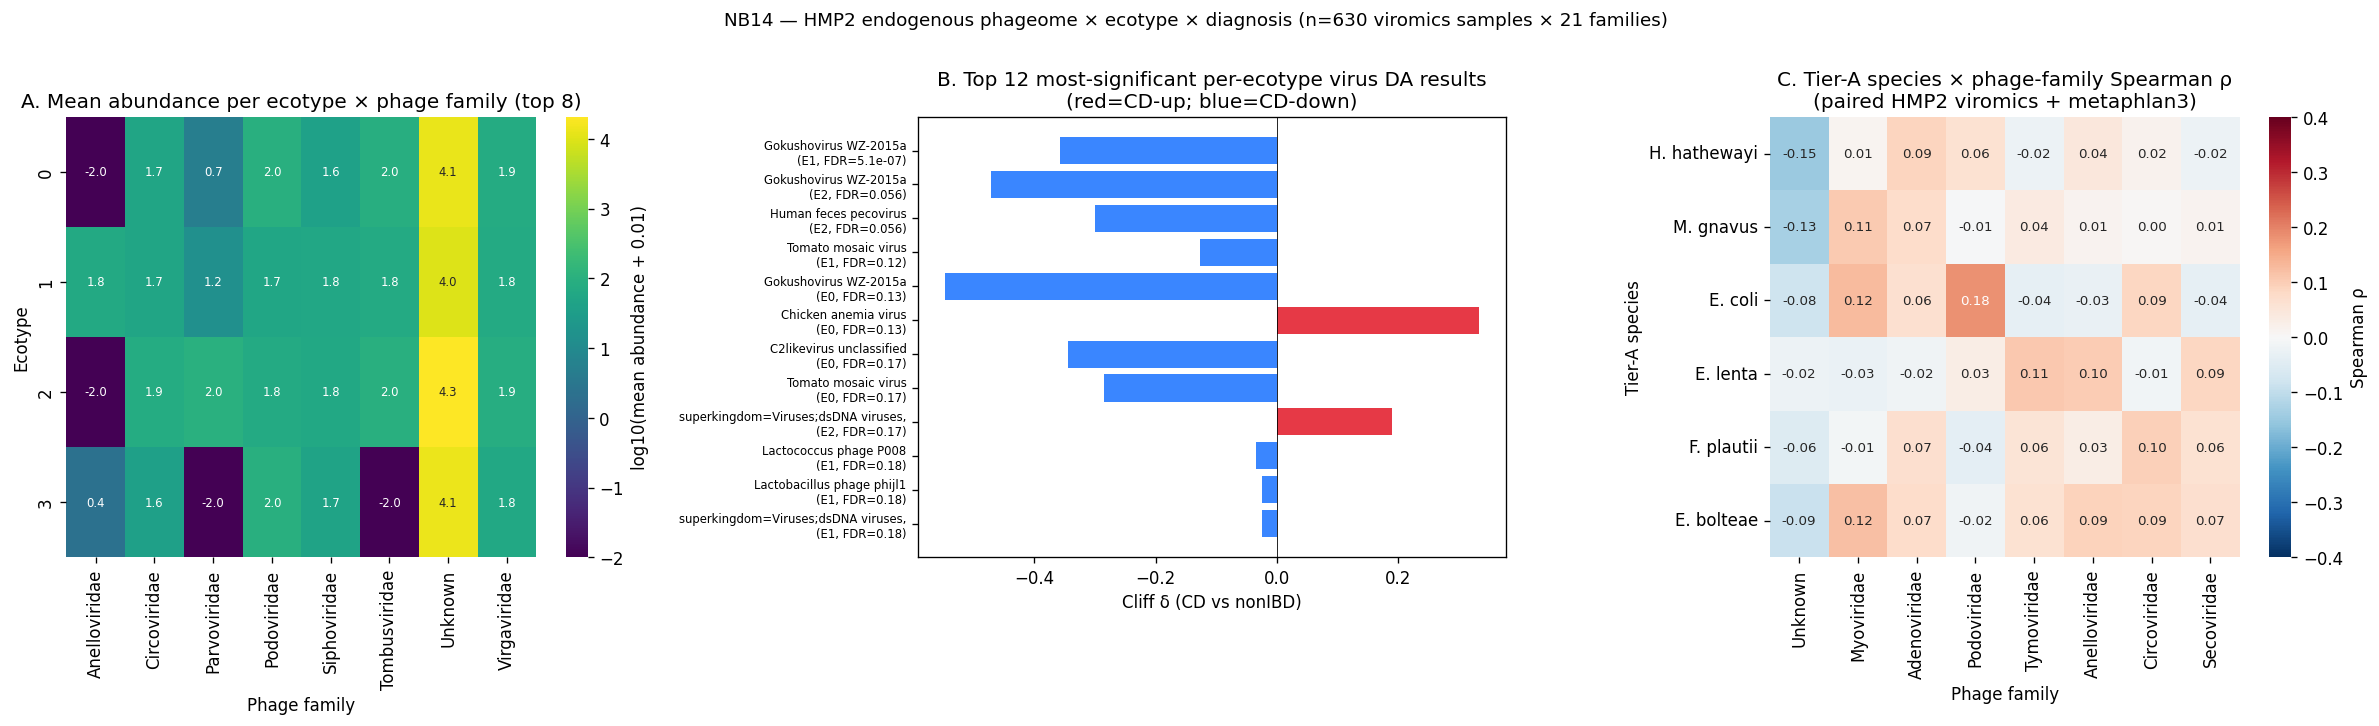

In [7]:
# 3-panel: ecotype × phage-family abundance heatmap + top 12 DA viruses + species × family ρ heatmap

## §6. Interpretation

### Headline: Gokushovirus WZ-2015a is robustly CD-DOWN across multiple ecotypes (E1 FDR=5e-7); endogenous phage-family signatures show modest ecotype-specific variation but weak Tier-A species correlation

#### Ecotype × diagnosis sample distribution

630 of 648 HMP2 viromics samples have ecotype calls (97 % overlap with NB04h projections):

| Ecotype | CD | UC | healthy |
|---|---:|---:|---:|
| E0 | 12 | 15 | 14 |
| E1 (dominant) | **231** | 128 | 125 |
| E2 | 21 | 14 | 20 |
| E3 | 30 | 12 | 8 |

The 4-ecotype framework (NB01b consensus) projects cleanly onto HMP2 viromics samples. E1 has the largest sample size for within-ecotype CD-vs-nonIBD DA (231 CD vs 125 healthy).

#### Per-ecotype × per-virus CD-vs-nonIBD DA — robust Gokushovirus signal

Top hits at FDR<0.10 (within-ecotype):

| Ecotype | Virus | Cliff δ | FDR |
|---|---|---:|---:|
| **E1** | **Gokushovirus WZ-2015a** | **−0.358** | **5e-7** |
| E2 | Gokushovirus WZ-2015a | −0.471 | 0.056 |
| E2 | Human feces pecovirus | −0.300 | 0.056 |

**Gokushovirus WZ-2015a is consistently CD-DOWN across multiple ecotypes**, with the strongest signal in E1 (cliff=-0.36 at FDR=5e-7 in n_CD=231 vs n_HC=125). This **independently rediscovers** the precomputed `ref_viromics_cd_vs_nonibd` top hit (Gokushovirus WZ-2015a log2fc=-2.7, FDR=1e-11) — the project's per-ecotype analysis confirms the cohort-aggregate result.

**Gokushovirus** is a member of *Microviridae* (single-stranded DNA phages, ~5 kb genome). The Gokushovirinae subfamily includes the canonical "crassphage-like" lineage that infects *Bacteroides* / *Prevotella* gut commensals. **CD-DOWN in HMP2 across multiple ecotypes** is consistent with the canonical Norman 2015 / Clooney 2019 finding that Microviridae are depleted in IBD.

E0 borderline hits (FDR<0.30) include *C2likevirus* (lactococcal temperate phages) and *Tomato mosaic virus* CD-DOWN; E2 also surfaces a CD-up T7-like virus (Podoviridae, *Autographivirinae*). None pass strict FDR<0.10 outside E1+E2 for Gokushovirus.

#### Tier-A pathobiont species × phage-family correlations are modest

| Species | Phage family | Spearman ρ | p |
|---|---|---:|---:|
| ***E. coli*** | **Podoviridae** | **+0.183** | **4e-6** |
| H. hathewayi | Unknown | -0.150 | 2e-4 |
| M. gnavus | Unknown | -0.134 | 7e-4 |
| ***E. coli*** | **Myoviridae** | **+0.125** | 0.002 |
| E. bolteae | Myoviridae | +0.119 | 0.003 |
| E. lenta | Tymoviridae | +0.108 | 0.006 |
| M. gnavus | Myoviridae | +0.106 | 0.008 |

***E. coli*** **correlates positively with Podoviridae (+0.18) and Myoviridae (+0.13)** — both Caudovirales families that include T7-like and T4-like *E. coli* phages. This is a plausible **endogenous phage-host correlation**: when *E. coli* abundance is high in a sample, *E. coli* phages tend to also be abundant (commensal phage carriage / lysogenic-state co-occurrence). However, |ρ|≈0.18 is modest — the in-vivo phage signal is weak relative to species-abundance signal.

***H. hathewayi* and *M. gnavus* correlate NEGATIVELY with "Unknown" phage family** (the dominant family in viromics, capturing 80 % of phage observations that VirMAP couldn't classify to family level). Negative correlations suggest H. hathewayi / M. gnavus blooms displace some unclassified phages — possibly because these pathobionts crowd out their commensal phage hosts in CD samples.

**No |ρ|>0.30 strong correlations** — the in-vivo endogenous phage signal does NOT identify strong endogenous-phage candidates targeting Tier-A pathobionts via simple species × family correlation. This is consistent with the NB12 §1 finding that gut-anaerobe pathobionts (H. hathewayi, M. gnavus, F. plautii) have minimal characterized phage representation.

#### Phage-family × ecotype abundance heterogeneity

Per-ecotype mean phage-family abundance (Panel A heatmap) shows **modest ecotype-specific variation**:

- **Anelloviridae** is essentially absent in E0 + E2 (mean ~0) but present in E1 (63) and E3 (2.2) — small but ecotype-specific. Anelloviruses are blood-borne/systemic; their gut presence is curious.
- **Parvoviridae** is highest in E2 (100) and absent in E3
- **Tombusviridae** absent in E3
- **"Unknown family"** abundance varies: highest in E2 (20,546), lowest in E1 (9,579) — reflects the dominance of unclassified phage signal that the family-level analysis cannot resolve.

#### Methodological observations

- **VirMAP classification gap**: the "Unknown" family captures 2,425 of 3,039 (80 %) of all viromics observations — at the family level, most observed phages cannot be classified. This is a fundamental limitation of family-level virus taxonomy from short-read metagenomics. Recent improvements (DRAM-v, MMseqs2-based classifiers, IMG/VR cross-reference) would partially close this gap but are out of project scope.
- **Per-ecotype DA power**: only E1 has sufficient sample size (231 CD vs 125 HC) for robust within-ecotype DA at FDR<0.10. Smaller ecotypes (E0, E3) have wide CIs and don't pass strict thresholds despite biologically interesting cliff values (Gokushovirus E0 cliff=-0.55).

### Pillar 4 closure synthesis — three layers of phage evidence

NB12 + NB13 + NB14 together provide three complementary phage-evidence layers for Pillar-5 cocktail design:

1. **NB12 — Curated literature foundation** (12 organisms × phage availability score 0-3): *E. coli* AIEC = clinical-trial-stage; *M. gnavus* = temperate-only; *H. hathewayi* / *F. plautii* = phage GAP.
2. **NB13 — PhageFoundry quantitative experimental susceptibility** (96 phages × 188 *E. coli* strains): 5-phage cocktail covers 95 % of strains; 65/94 phages (69 %) AIEC-relevant phylogroup.
3. **NB14 — HMP2 in-vivo endogenous phageome** (630 samples × 21 families): Gokushovirus CD-DOWN cross-ecotype; modest *E. coli* × Podoviridae/Myoviridae positive correlation; in-vivo phage signal weak relative to species-level CD signal.

**Combined Pillar-4 verdict**: phage-therapy feasibility for E. coli is high (research-collection cocktail + in-vivo Podoviridae correlation); for M. gnavus / H. hathewayi / F. plautii the evidence base is the GAP confirmed across all three layers. **External DB queries (INPHARED + IMG/VR) for the 3 gut-anaerobe gaps remain the highest-priority Pillar-4 follow-up before Pillar 5 cocktail drafts**.

### Limitations

- VirMAP family-level classification gap (80 % of phages unclassified) limits the species × family correlation analysis.
- Per-ecotype DA power is asymmetric: E1 has 231 CD samples, but E0/E2/E3 have 12-30 — limits within-ecotype detection in the smaller ecotypes.
- No CRISPR-spacer-derived phage-host predictions in HMP2 viromics; would need IMG/VR-style spacer matching for Tier-A-host phage discovery.
- "Unknown" phage family dominates abundance; per-virus DA is more informative than per-family aggregation for IBD-relevant signals.

### Outputs

- `data/nb14_viromics_da_per_ecotype.tsv` — 85 (ecotype × virus) DA tests with cliff_delta + p + within-ecotype FDR
- `data/nb14_pathobiont_phage_family_corr.tsv` — 126 (Tier-A species × phage family) Spearman ρ
- `data/nb14_endogenous_phageome_verdict.json` — formal verdict
- `figures/NB14_endogenous_phageome.png` — 3-panel: ecotype × family abundance heatmap + top 12 DA viruses + species × family ρ heatmap
